In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../../style_Matplotlib_charts.mplstyle")
from sklearn.linear_model import LinearRegression
import pickle
from sklearn.preprocessing import PolynomialFeatures

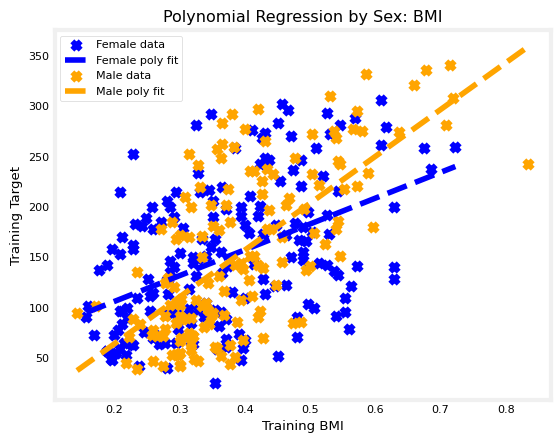

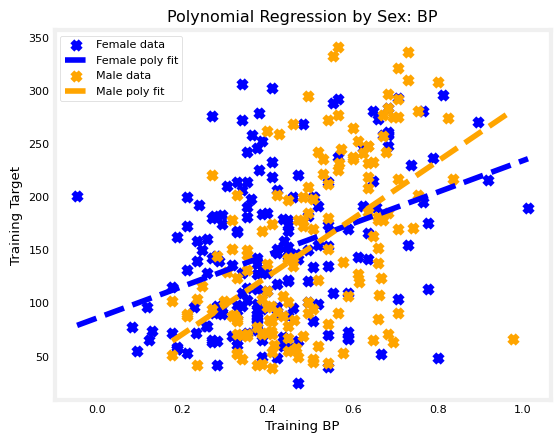

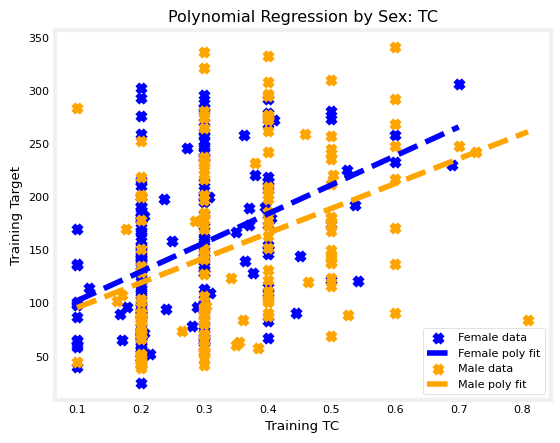

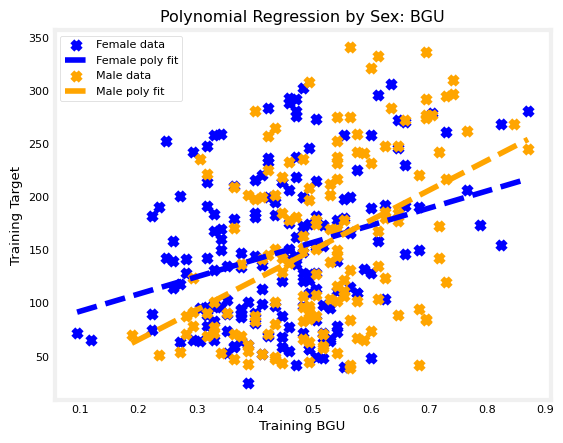

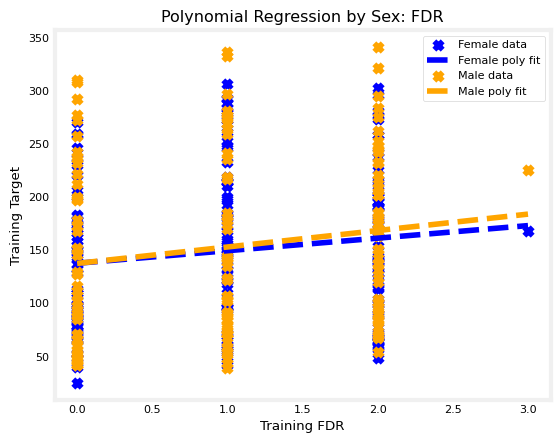

In [2]:
features = ["SEX", "BMI", "BP", "TC", "BGU", "FDR"]

# Create a data frame from the csv file
training_data = pd.read_csv("2.3.2.training_data.csv")

sex_labels = {-1: "Female", 1: "Male"}
sex_colors = {-1: "blue", 1: "orange"}

degree = 1  # You can adjust the polynomial degree

for item in features:
    if item == "SEX":
        continue  # Skip plotting SEX vs Target
    x_name = item
    y_name = "Target"
    plt.figure()
    for sex_value, label in sex_labels.items():
        mask = training_data["SEX"] == sex_value
        x = np.array(training_data.loc[mask, x_name]).reshape(-1, 1)
        y = np.array(training_data.loc[mask, y_name])
        # Fit polynomial regression
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        x_poly = poly.fit_transform(x)
        model = LinearRegression()
        model.fit(x_poly, y)
        # Predict for plotting
        x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        x_plot_poly = poly.transform(x_plot)
        y_plot = model.predict(x_plot_poly)
        # Scatter and line plot
        plt.scatter(x, y, marker="x", color=sex_colors[sex_value], label=f"{label} data")
        plt.plot(x_plot, y_plot, color=sex_colors[sex_value], linestyle="--", label=f"{label} poly fit")
    plt.title(f"Polynomial Regression by Sex: {x_name}")
    plt.ylabel(f"Training {y_name}")
    plt.xlabel(f"Training {x_name}")
    plt.legend()
    plt.show()